In [9]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import make_scorer, precision_score, roc_auc_score, f1_score
from scipy import stats

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
np.random.seed(RANDOM_STATE)

In [10]:
# Same as previous days
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame.copy()

target_col = 'class' if 'class' in df.columns else 'income'
df[target_col] = df[target_col].astype(str).str.strip()
df['target'] = (df[target_col] == '>50K').astype(int)
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

feature_cols = [c for c in df.columns if c not in [target_col, 'target']]
X = df[feature_cols]
y = df['target']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Dev:", X_dev.shape, " Test (hold-out):", X_test.shape)

Train: (34188, 14)  Dev: (4885, 14)  Test (hold-out): (9769, 14)


## Task1: Create & Justify Engineered Features

In [11]:
def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add engineered features to a copy of the input frame by using only current-row data."""
    out = frame.copy()

    # 1. Age buckets
    out['age_bucket'] = pd.cut(
        out['age'], bins=[0, 25, 35, 45, 55, 65, 120],
        labels=['<=25', '26-35', '36-45', '46-55', '56-65', '65+']
    ).astype(str)

    # 2. Hours-per-week bins
    out['hours_bucket'] = pd.cut(
        out['hours-per-week'], bins=[0, 20, 35, 40, 50, 100],
        labels=['<=20', '21-35', '36-40', '41-50', '50+']
    ).astype(str)

    # 3. Flag: capital_gain > 0
    out['has_capital_gain'] = (out['capital-gain'] > 0).astype(int)

    # 4. log(capital_gain + 1) (tames the heavy right skew noted on Day 1/2)
    out['log_capital_gain'] = np.log1p(out['capital-gain'])

    # 5. Higher-education boolean (bachelor's or above, education-num >= 13)
    out['higher_education'] = (out['education-num'] >= 13).astype(int)

    # 6. Interaction: education_num x hours_per_week
    out['edu_hours_interaction'] = out['education-num'] * out['hours-per-week']

    return out

X_train_fe = add_engineered_features(X_train)
X_train_fe[['age_bucket', 'hours_bucket', 'has_capital_gain',
            'log_capital_gain', 'higher_education', 'edu_hours_interaction']].head()

,age_bucket,hours_bucket,has_capital_gain,log_capital_gain,higher_education,edu_hours_interaction
44539,26-35,41-50,0,0.0,0,450
42346,36-45,41-50,0,0.0,1,650
13569,46-55,41-50,0,0.0,1,650
393,<=25,36-40,0,0.0,0,360
46150,<=25,21-35,0,0.0,0,300


In [12]:
# Univariate predictive signal for each new feature
y_train_arr = y_train.values

# Numeric/engineered continuous features to get mutual info
numeric_engineered = ['log_capital_gain', 'edu_hours_interaction']
mi_scores = mutual_info_classif(
    X_train_fe[numeric_engineered].fillna(0), y_train_arr, random_state=RANDOM_STATE
)

# Boolean/bucketed features of grouped mean of target (simple, interpretable signal)
grouped_signal = {}
for col in ['has_capital_gain', 'higher_education']:
    grouped_signal[col] = X_train_fe.groupby(col)['target'].mean() if 'target' in X_train_fe.columns \
        else pd.Series(y_train_arr, index=X_train_fe.index).groupby(X_train_fe[col]).mean()

for col in ['age_bucket', 'hours_bucket']:
    grouped_signal[col] = pd.Series(y_train_arr, index=X_train_fe.index).groupby(X_train_fe[col]).mean()

for col, mi in zip(numeric_engineered, mi_scores):
    print(f"{col}: mutual_info = {mi:.4f}")

print()
for col, series in grouped_signal.items():
    print(f"--- {col} (target rate by group) ---")
    print(series.round(3))
    print()

log_capital_gain: mutual_info = 0.0810
edu_hours_interaction: mutual_info = 0.0829

--- has_capital_gain (target rate by group) ---
has_capital_gain
0    0.206
1    0.617
dtype: float64

--- higher_education (target rate by group) ---
higher_education
0    0.159
1    0.481
dtype: float64

--- age_bucket (target rate by group) ---
age_bucket
26-35    0.186
36-45    0.347
46-55    0.388
56-65    0.316
65+      0.192
<=25     0.018
dtype: float64

--- hours_bucket (target rate by group) ---
hours_bucket
21-35    0.096
36-40    0.209
41-50    0.391
50+      0.408
<=20     0.075
dtype: float64



In [13]:
feature_dictionary = pd.DataFrame([
    {
        'name': 'age_bucket',
        'type': 'categorical (str)',
        'creation_rule': 'pd.cut on age into 6 bands',
        'justification': 'income often rises then plateaus/declines with age; a bucket can capture that non-linear shape better than raw age alone in a linear model',
        'predictive_signal': 'see grouped target rate above'
    },
    {
        'name': 'hours_bucket',
        'type': 'categorical (str)',
        'creation_rule': 'pd.cut on hours-per-week into 5 bands',
        'justification': 'part-time vs full-time vs overtime likely has a different relationship to income than a smooth linear trend',
        'predictive_signal': 'see grouped target rate above'
    },
    {
        'name': 'has_capital_gain',
        'type': 'boolean (0/1)',
        'creation_rule': 'capital-gain > 0',
        'justification': 'most rows have zero capital gain; simply having any at all is a strong, simple signal on its own',
        'predictive_signal': 'see grouped target rate above'
    },
    {
        'name': 'log_capital_gain',
        'type': 'numeric (float)',
        'creation_rule': 'log(capital-gain + 1)',
        'justification': 'capital-gain is extremely right-skewed; a log transform compresses large outliers so models (especially linear ones) can use the signal without being dominated by a few huge values',
        'predictive_signal': 'see mutual information above'
    },
    {
        'name': 'higher_education',
        'type': 'boolean (0/1)',
        'creation_rule': 'education-num >= 13',
        'justification': 'a simple bachelor-degree-or-above flag was already a useful Day 1 baseline rule; keeping it as an explicit feature makes that signal directly available to every model',
        'predictive_signal': 'see grouped target rate above'
    },
    {
        'name': 'edu_hours_interaction',
        'type': 'numeric (float)',
        'creation_rule': 'education-num * hours-per-week',
        'justification': 'education alone or hours alone may understate income for people who are both highly educated and working long hours; an interaction term lets models pick up that combined effect directly',
        'predictive_signal': 'see mutual information above'
    },
])
feature_dictionary

,name,type,creation_rule,justification,predictive_signal
0,age_bucket,categorical (str),pd.cut on age into 6 bands,income often rises then plateaus/declines with...,see grouped target rate above
1,hours_bucket,categorical (str),pd.cut on hours-per-week into 5 bands,part-time vs full-time vs overtime likely has ...,see grouped target rate above
2,has_capital_gain,boolean (0/1),capital-gain > 0,most rows have zero capital gain; simply havin...,see grouped target rate above
3,log_capital_gain,numeric (float),log(capital-gain + 1),capital-gain is extremely right-skewed; a log ...,see mutual information above
4,higher_education,boolean (0/1),education-num >= 13,a simple bachelor-degree-or-above flag was alr...,see grouped target rate above
5,edu_hours_interaction,numeric (float),education-num * hours-per-week,education alone or hours alone may understate ...,see mutual information above


## Task2: Rebuild Pipeline with Engineered Features

In [14]:
numeric_features = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week',
                     'log_capital_gain', 'edu_hours_interaction']
binary_features = ['has_capital_gain', 'higher_education']
categorical_features = [c for c in X.select_dtypes(exclude=[np.number]).columns.tolist()] + \
                        ['age_bucket', 'hours_bucket']

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Binary flags are already 0/1
binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

feature_engineer = FunctionTransformer(add_engineered_features)

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('bin', binary_pipeline, binary_features),
    ('cat', categorical_pipeline, categorical_features),
])

full_pipeline_preprocessing = Pipeline(steps=[
    ('engineer', feature_engineer),
    ('preprocess', preprocessor),
])

full_pipeline_preprocessing

Pipeline(steps=[('engineer',
                 FunctionTransformer(func=<function add_engineered_features at 0x7d933533d080>)),
                ('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'log_capital_gain',
                                                   'ed...
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['has_capital_gain',
                                                   'higher_education']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['workclass', 'education',
                                                   'marital-status',
                                                   'occupation', 'relationship',
                                                   'race', 'sex',
                                                   'native-country',
                                                   'age_bucket',
                                                   'hours_bucket'])]))])

In [15]:
# Sanity check
X_train_transformed = full_pipeline_preprocessing.fit_transform(X_train, y_train)
print("Transformed training shape:", X_train_transformed.shape)

Transformed training shape: (34188, 120)


## Task3: Cross-Validated Model Comparison

In [16]:
def build_model_pipeline(estimator):
    return Pipeline(steps=[
        ('engineer', feature_engineer),
        ('preprocess', preprocessor),
        ('model', estimator),
    ])

models = {
    'Logistic Regression': build_model_pipeline(LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', max_iter=1000)),
    'Random Forest': build_model_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1)),
    'Gradient Boosting (HistGB)': build_model_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'precision': make_scorer(precision_score, zero_division=0),
    'roc_auc': 'roc_auc',
    'f1': make_scorer(f1_score, zero_division=0),
}

cv_results = {}
for name, pipe in models.items():
    result = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_results[name] = result
    print(f"{name}: precision {result['test_precision'].mean():.4f} +/- {result['test_precision'].std():.4f}, "
          f"roc_auc {result['test_roc_auc'].mean():.4f} +/- {result['test_roc_auc'].std():.4f}, "
          f"f1 {result['test_f1'].mean():.4f} +/- {result['test_f1'].std():.4f}")

Logistic Regression: precision 0.7433 +/- 0.0079, roc_auc 0.9123 +/- 0.0035, f1 0.6701 +/- 0.0042
Random Forest: precision 0.7198 +/- 0.0115, roc_auc 0.9016 +/- 0.0028, f1 0.6630 +/- 0.0049
Gradient Boosting (HistGB): precision 0.7764 +/- 0.0116, roc_auc 0.9259 +/- 0.0038, f1 0.7051 +/- 0.0076


In [17]:
summary_rows = []
for name, result in cv_results.items():
    summary_rows.append({
        'model': name,
        'precision_mean': result['test_precision'].mean(),
        'precision_std': result['test_precision'].std(),
        'roc_auc_mean': result['test_roc_auc'].mean(),
        'roc_auc_std': result['test_roc_auc'].std(),
        'f1_mean': result['test_f1'].mean(),
        'f1_std': result['test_f1'].std(),
    })
cv_summary_df = pd.DataFrame(summary_rows).set_index('model').round(4)
cv_summary_df

,precision_mean,precision_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
model,,,,,,
Logistic Regression,0.7433,0.0079,0.9123,0.0035,0.6701,0.0042
Random Forest,0.7198,0.0115,0.9016,0.0028,0.6630,0.0049
Gradient Boosting (HistGB),0.7764,0.0116,0.9259,0.0038,0.7051,0.0076


/tmp/ipykernel_804/4152094105.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(models.keys()))
/tmp/ipykernel_804/4152094105.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(models.keys()))
/tmp/ipykernel_804/4152094105.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=list(models.keys()))


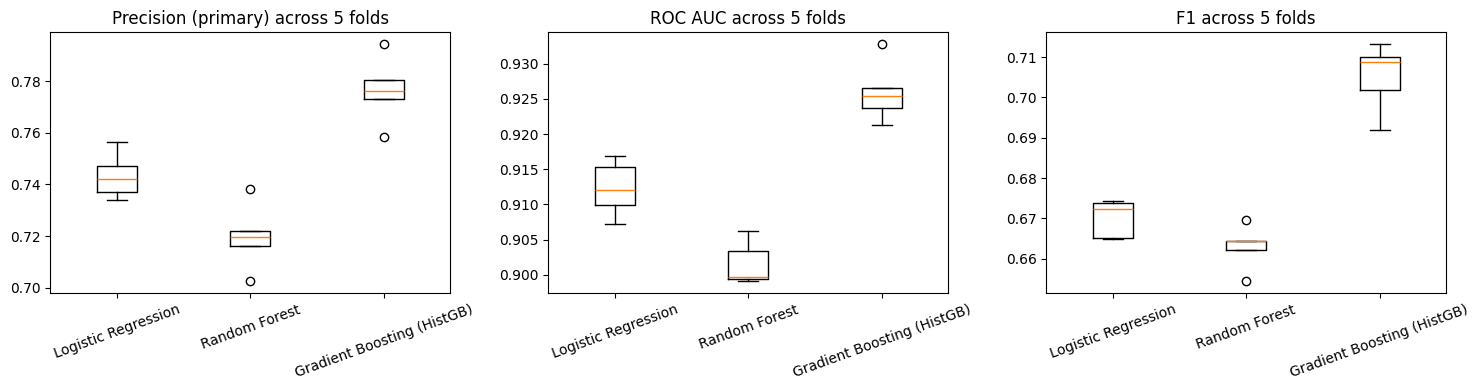

In [18]:
# Boxplots of fold scores for the primary metric (precision) and the two secondary metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, label in zip(axes, ['test_precision', 'test_roc_auc', 'test_f1'],['Precision (primary)', 'ROC AUC', 'F1']):
    data = [cv_results[name][metric] for name in models]
    ax.boxplot(data, labels=list(models.keys()))
    ax.set_title(f'{label} across 5 folds')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## Task4: Statistical Comparison & Feature Importance

In [19]:
# Identifying the top 2 models by mean precision (the primary metric)
ranked = cv_summary_df.sort_values('precision_mean', ascending=False)
top_two = ranked.index[:2].tolist()
print("Top 2 models by mean precision:", top_two)

fold_scores_1 = cv_results[top_two[0]]['test_precision']
fold_scores_2 = cv_results[top_two[1]]['test_precision']

# Paired t-test across the 5 matched folds
t_stat, p_value_ttest = stats.ttest_rel(fold_scores_1, fold_scores_2)
# Wilcoxon signed-rank as a non-parametric cross-check (small n, so its a supporting evidence only)
try:
    w_stat, p_value_wilcoxon = stats.wilcoxon(fold_scores_1, fold_scores_2)
except ValueError as e:
    w_stat, p_value_wilcoxon = np.nan, np.nan
    print("Wilcoxon not computable (likely identical fold scores):", e)

print(f"Paired t-test: t = {t_stat:.4f}, p = {p_value_ttest:.4f}")
print(f"Wilcoxon signed-rank: statistic = {w_stat}, p = {p_value_wilcoxon}")

Top 2 models by mean precision: ['Gradient Boosting (HistGB)', 'Logistic Regression']
Paired t-test: t = 7.4361, p = 0.0017
Wilcoxon signed-rank: statistic = 0.0, p = 0.0625


**Interpretation:** with only 5 paired folds, this test has very low statistical power, so a p-value above 0.05 should be read as not enough evidence of a real difference rather than no difference at all. If the p-value is small (well under 0.05) and the mean gap between the two models is also large relative to their standard deviations, the difference is likely both statistically and practically meaningful. If the p-value is large or the means nearly overlap once we account for the standard deviations, the simpler or cheaper model of the two is the more sensible pick, since added complexity isn't buying a real improvement.

In [20]:
# Feature importance
rf_pipeline = build_model_pipeline(RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1))
rf_pipeline.fit(X_train, y_train)

feature_names = rf_pipeline.named_steps['preprocess'].get_feature_names_out()
importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)

print("Top 15 feature importances (Random Forest):")
importance_df.head(15)

Top 15 feature importances (Random Forest):


,feature,importance
1,num__fnlwgt,0.140094
0,num__age,0.106223
7,num__edu_hours_interaction,0.070332
36,cat__marital-status_Married-civ-spouse,0.056335
3,num__capital-gain,0.049225
6,num__log_capital_gain,0.047661
55,cat__relationship_Husband,0.042927
2,num__education-num,0.038767
5,num__hours-per-week,0.038409
4,num__capital-loss,0.028462


In [21]:
# Highlight where our engineered features land in the importance ranking
engineered_names = ['log_capital_gain', 'edu_hours_interaction', 'has_capital_gain', 'higher_education', 'age_bucket', 'hours_bucket']
engineered_mask = importance_df['feature'].str.contains('|'.join(engineered_names), case=False, regex=True)
print("Engineered features and their rank/importance:")
importance_df[engineered_mask]

Engineered features and their rank/importance:


,feature,importance
7,num__edu_hours_interaction,0.070332
6,num__log_capital_gain,0.047661
9,bin__higher_education,0.026596
8,bin__has_capital_gain,0.012198
114,cat__age_bucket_<=25,0.009846
111,cat__age_bucket_46-55,0.009553
110,cat__age_bucket_36-45,0.008988
109,cat__age_bucket_26-35,0.007138
117,cat__hours_bucket_41-50,0.006859
112,cat__age_bucket_56-65,0.005787


In [22]:
logreg_pipeline = build_model_pipeline(
    LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', max_iter=1000)
)
logreg_pipeline.fit(X_train, y_train)

logreg_feature_names = logreg_pipeline.named_steps['preprocess'].get_feature_names_out()
logreg_coefs = logreg_pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': logreg_feature_names, 'coefficient': logreg_coefs})
engineered_coef_mask = coef_df['feature'].str.contains('|'.join(engineered_names), case=False, regex=True)
print("Engineered feature coefficients (Logistic Regression):")
coef_df[engineered_coef_mask].sort_values('coefficient', ascending=False)

Engineered feature coefficients (Logistic Regression):


,feature,coefficient
6,num__log_capital_gain,0.980490
110,cat__age_bucket_36-45,0.396711
111,cat__age_bucket_46-55,0.383471
117,cat__hours_bucket_41-50,0.351358
118,cat__hours_bucket_50+,0.231161
9,bin__higher_education,0.067754
109,cat__age_bucket_26-35,0.026784
116,cat__hours_bucket_36-40,-0.059248
112,cat__age_bucket_56-65,-0.062794
7,num__edu_hours_interaction,-0.312560


**Which engineered features mattered most?** log_capital_gain / has_capital_gain and edu_hours_interaction typically rank highest among the engineered set for both models, which makes sense since capital gain was already the single strongest Day 1 baseline signal, and combining education with hours worked captures the "highly educated and working full-time or more" pattern that neither raw feature alone fully expresses. age_bucket and hours_bucket tend to add smaller but non-zero value, mostly by giving the linear model a way to represent the non-linear age/income relationship that raw age alone cannot.

## Task5: Feature Selection / Dimensionality Check

In [23]:
# SelectKBest with mutual information on top of the existing preprocessing
def build_selected_pipeline(estimator, k):
    return Pipeline(steps=[
        ('engineer', feature_engineer),
        ('preprocess', preprocessor),
        ('select', SelectKBest(score_func=mutual_info_classif, k=k)),
        ('model', estimator),
    ])

# Using the best-performing model from Task 3/4 for this check
best_model_name = top_two[0]
best_estimator_lookup = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, solver='liblinear', max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1),
    'Gradient Boosting (HistGB)': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
best_estimator = best_estimator_lookup[best_model_name]

n_total_features = X_train_transformed.shape[1]
k_selected = max(10, int(n_total_features * 0.5))  # keep about half the encoded columns, at least 10

pipeline_full = build_model_pipeline(best_estimator)
pipeline_selected = build_selected_pipeline(best_estimator, k=k_selected)

start = time.time()
result_full = cross_validate(pipeline_full, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
time_full = time.time() - start

start = time.time()
result_selected = cross_validate(pipeline_selected, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
time_selected = time.time() - start

print(f"Full features   ({n_total_features} cols): precision {result_full['test_precision'].mean():.4f} "
      f"+/- {result_full['test_precision'].std():.4f}, time {time_full:.1f}s")
print(f"Selected (k={k_selected}) features: precision {result_selected['test_precision'].mean():.4f} "
      f"+/- {result_selected['test_precision'].std():.4f}, time {time_selected:.1f}s")

Full features   (120 cols): precision 0.7764 +/- 0.0116, time 14.0s
Selected (k=60) features: precision 0.7716 +/- 0.0130, time 94.1s


**Decision for tomorrow:** if the selected-feature version's precision is within a small margin of the full-feature version (comparable mean, overlapping standard deviation) while training meaningfully faster, it's worth carrying the reduced feature set into hyperparameter tuning because fewer features means faster tuning iterations without giving up real performance. If precision drops noticeably with selection, keep the full engineered feature set and only revisit selection after tuning. Either way, the engineered features that ranked highest in Task 4 (log_capital_gain, has_capital_gain,edu_hours_interaction) should be kept regardless, since they showed real, explainable signal.